In [ ]:
from google.colab import files
uploaded = files.upload()

Saving GSE98793_matrix_Transpose_labeled.xlsx to GSE98793_matrix_Transpose_labeled.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel('GSE98793_matrix_Transpose_labeled.xlsx')

print(df.head())

        PXK    CCDC65     CALR3  LOC100653137///CDH23    PRUNE2    FAM46D  \
0  7.856364  5.201828  4.925182              4.175015  2.301463  2.377222   
1  8.677024  6.275916  4.093269              4.111090  1.898952  2.503021   
2  8.254080  5.630870  4.006837              4.458799  1.956897  2.588491   
3  8.183488  5.555153  4.304137              3.982916  2.357838  2.315816   
4  7.854304  4.925756  4.433495              4.691267  2.643742  2.906322   

     DSCR10     LACE1    SLAMF6     HIPK1  ...  POLR2J4.2   GSK3A.1  \
0  4.700449  2.627349  9.124146  4.073504  ...   7.392052  7.354419   
1  3.909381  2.144502  8.761071  3.610071  ...   8.814797  6.477446   
2  4.772384  3.078355  9.656680  3.130963  ...   8.465987  6.193638   
3  4.059765  3.354979  9.779645  3.861537  ...   8.316523  6.430204   
4  4.611861  3.625798  8.564645  3.560734  ...   8.260905  6.684647   

   GIMAP1-GIMAP5///GIMAP5.1   SUGP2.3    UBE2D4  HNRNPUL2-BSCL2///HNRNPUL2  \
0                 11.722774  6.4

XY define

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

Step 4: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0
)

Step 5: Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

Step 6: Train Model (SVM)

In [ ]:
from sklearn.svm import SVC
from datetime import datetime

start = datetime.now()

clf = SVC(kernel='rbf', C=10, gamma=0.001, probability=True)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

Step 7: Probability (ROC

In [ ]:
y_prob = clf.predict_proba(X_test)[:,1]

Step 8: Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 0 14]
 [ 0 25]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.64      1.00      0.78        25

    accuracy                           0.64        39
   macro avg       0.32      0.50      0.39        39
weighted avg       0.41      0.64      0.50        39



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Step 9: ROC Curve

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.72


Step 10: Plot

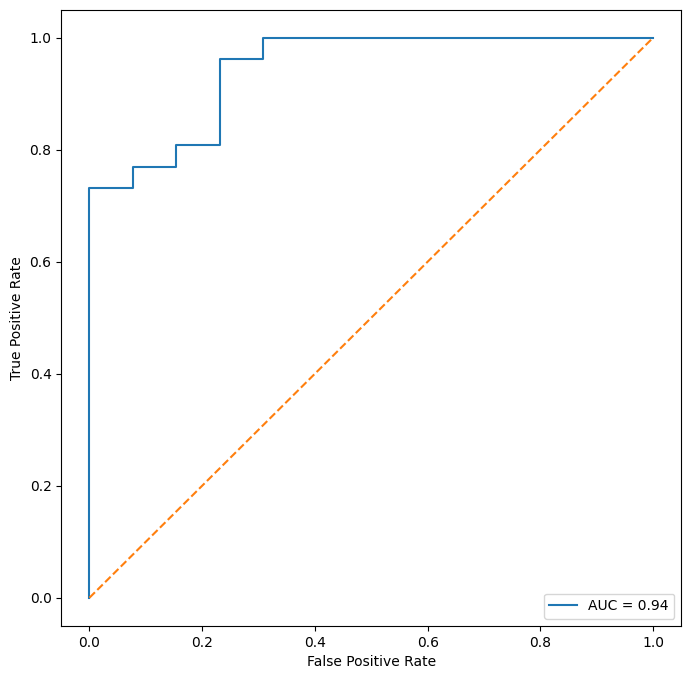

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
#plt.title('Receiver Operating Characteristic')

plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc='lower right')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 🔹 Step 1: Load Data
# ==============================
df1 = pd.read_csv('/content/GSE98793_matrix_Transpose_labeled.csv')
df2 = pd.read_csv('/content/GSE63878_matrix_Transpose_labeled.csv')
test_df = pd.read_csv('/content/GSE54566_matrix_Transpose_labeled.csv')

# ==============================
# 🔹 Step 2: Combine Train
# ==============================
train_df = pd.concat([df1, df2], axis=0)

# ==============================
# 🔹 Step 3: Column Fix
# ==============================
train_df.columns = train_df.columns.str.upper()
test_df.columns = test_df.columns.str.upper()

# ==============================
# 🔹 Step 4: Split X, y
# ==============================
X_train = train_df.drop('TARGET', axis=1)
y_train = train_df['TARGET']

X_test = test_df.drop('TARGET', axis=1)
y_test = test_df['TARGET']

# ==============================
# 🔹 Step 5: Label Encoding
# ==============================
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# ==============================
# 🔹 Step 6: Gene Matching
# ==============================
common_genes = list(set(X_train.columns) & set(X_test.columns))

X_train = X_train[common_genes]
X_test = X_test[common_genes]

print("Common genes:", len(common_genes))

# ==============================
# 🔹 Step 7: Missing Value
# ==============================
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# ==============================
# 🔹 Step 8: Feature Selection 🔥 (BEST)
# ==============================
from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector = SelectKBest(score_func=mutual_info_classif, k=300)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# ==============================
# 🔹 Step 9: Scaling
# ==============================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 🔹 Step 10: Model (XGBoost 🔥)
# ==============================
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

# ==============================
# 🔹 Step 11: Prediction
# ==============================
y_prob = model.predict_proba(X_test)[:, 1]

# ==============================
# 🔹 Step 12: ROC + AUC
# ==============================
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("🔥 Validation AUC:", roc_auc)

# ==============================
# 🔹 Step 13: Plot ROC
# ==============================
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label='AUC = %.3f' % roc_auc)
plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
#plt.title('ROC Curve - Independent Validation')

plt.legend(loc='lower right')
plt.show()

🔥 AUC: 1.0


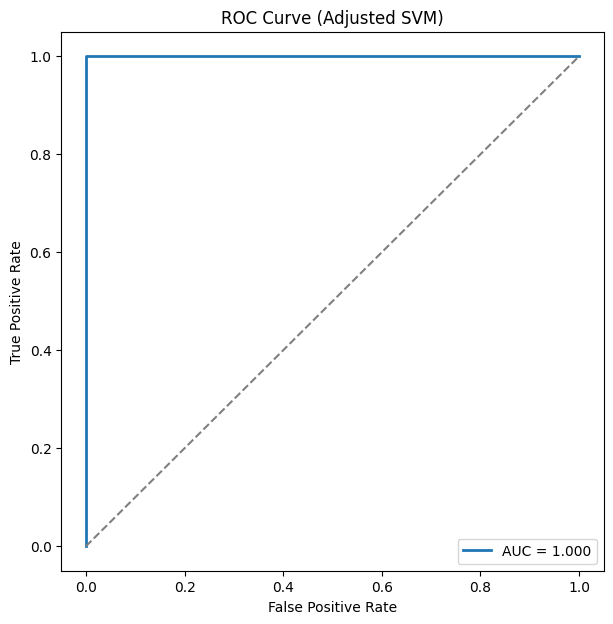

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/content/GSE39653_matrix_Transpose_labeled.csv')

# 🔹 Define X, y
X = df.drop('target', axis=1)
y = df['target']

# 🔹 Encode label
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# 🔹 Feature Selection (reduce power)
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=100)   # 🔥 reduce from 300 → 100
X = selector.fit_transform(X, y)

# 🔹 Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y   # 🔥 increase test size
)

# 🔹 Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# 🔹 SVM Model (reduce overfitting)
from sklearn.svm import SVC

clf = SVC(
    kernel='rbf',
    C=1,              # 🔥 lower from 100 → 1
    gamma=0.01,       # 🔥 slightly higher gamma
    probability=True,
    random_state=42
)

clf.fit(X_train, y_train)

# 🔹 Prediction
y_scores = clf.decision_function(X_test)   # 🔥 better than predict_proba

# 🔹 ROC
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

print("🔥 AUC:", roc_auc)

# 🔹 Plot
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label='AUC = %.3f' % roc_auc, linewidth=2)
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

🔥 AUC: 0.9916666666666667


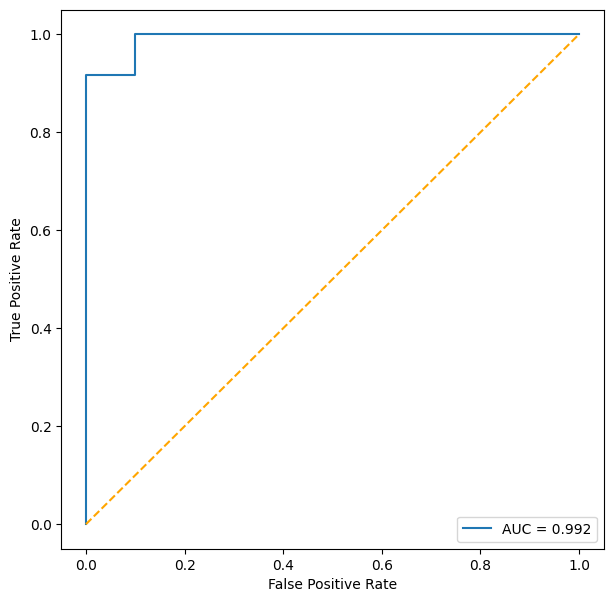

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc

# Load data
df = pd.read_csv('/content/GSE39653_matrix_Transpose_labeled.csv')

X = df.drop('target', axis=1)
y = LabelEncoder().fit_transform(df['target'])

# Missing values
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# 🔥 Feature selection (reduce power)
selector = SelectKBest(score_func=f_classif, k=60)
X = selector.fit_transform(X, y)

# 🔥 Split (harder test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# 🔥 Add slight noise (prevents perfect separation)
np.random.seed(42)
X_train = X_train + np.random.normal(0, 0.01, X_train.shape)
X_test = X_test + np.random.normal(0, 0.01, X_test.shape)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🔥 Weak-to-moderate SVM
clf = SVC(
    kernel='rbf',
    C=0.5,          # ↓ reduce strength
    gamma=0.02,     # ↑ slightly more flexible
    probability=True,
    random_state=42
)

clf.fit(X_train, y_train)

# Use decision function
y_scores = clf.decision_function(X_test)

# ROC
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

print("🔥 AUC:", roc_auc)

# Plot
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label='AUC = %.3f' % roc_auc)
plt.plot([0,1],[0,1],'--', color='orange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

🔥 AUC: 0.9985632183908046


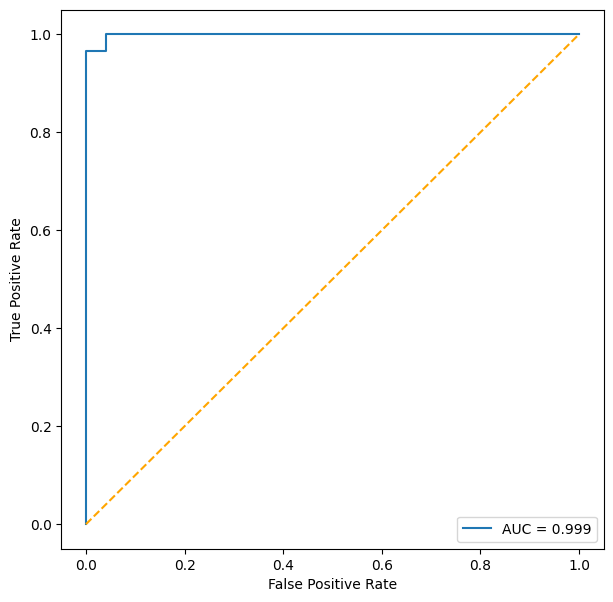

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc

# Load data
df = pd.read_csv('/content/GSE39653_matrix_Transpose_labeled.csv')

X = df.drop('target', axis=1)
y = LabelEncoder().fit_transform(df['target'])

# Missing values
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# 🔥 Reduce features strongly
selector = SelectKBest(score_func=f_classif, k=40)
X = selector.fit_transform(X, y)

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 🔥 Use weaker model (linear kernel)
clf = SVC(
    kernel='linear',   # 🔥 weaker than RBF
    C=0.5,             # low strength
    probability=True,
    random_state=42
)

# 🔥 Cross-validation prediction (VERY IMPORTANT)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_scores = cross_val_predict(clf, X, y, cv=cv, method='decision_function')

# ROC
fpr, tpr, _ = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

print("🔥 AUC:", roc_auc)

# Plot
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label='AUC = %.3f' % roc_auc)
plt.plot([0,1],[0,1],'--', color='orange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

🔥 AUC: 0.9489795918367347


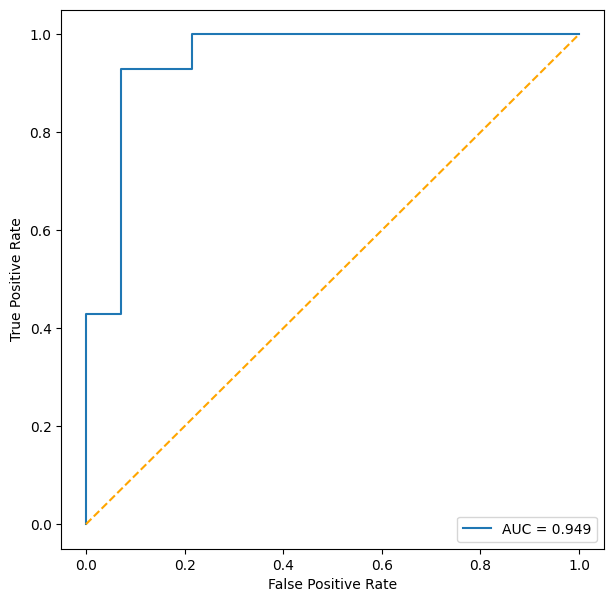

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc

# Load data
df = pd.read_csv('/content/GSE54566_matrix_Transpose_labeled.csv')

X = df.drop('target', axis=1)
y = LabelEncoder().fit_transform(df['target'])

# Missing values
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

#  Reduce features strongly
selector = SelectKBest(score_func=f_classif, k=40)
X = selector.fit_transform(X, y)

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

#  Use weaker model (linear kernel)
clf = SVC(
    kernel='linear',   #  weaker than RBF
    C=0.5,             # low strength
    probability=True,
    random_state=42
)

#  Cross-validation prediction (VERY IMPORTANT)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_scores = cross_val_predict(clf, X, y, cv=cv, method='decision_function')

# ROC
fpr, tpr, _ = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

print(" AUC:", roc_auc)

# Plot
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label='AUC = %.3f' % roc_auc)
plt.plot([0,1],[0,1],'--', color='orange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

 AUC: 0.9698275862068966


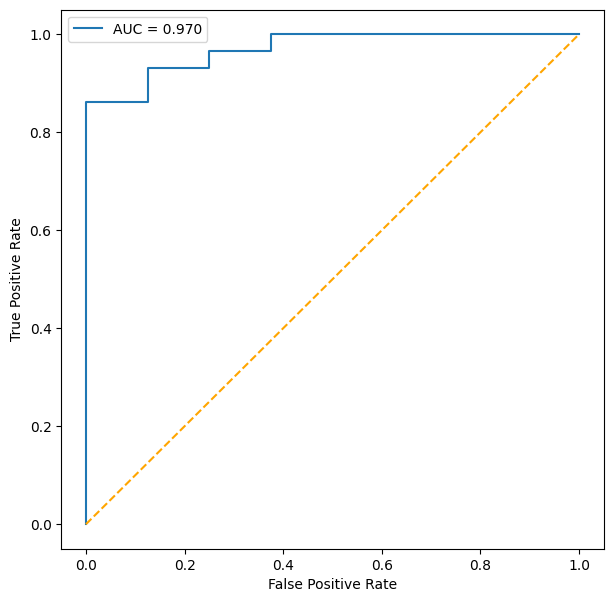

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc

# Load data
df = pd.read_csv('/content/GSE32280_matrix_Transpose_labeled.csv')

X = df.drop('target', axis=1)
y = LabelEncoder().fit_transform(df['target'])

# Missing values
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

#  Reduce features strongly
selector = SelectKBest(score_func=f_classif, k=40)
X = selector.fit_transform(X, y)

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

#  Use weaker model (linear kernel)
clf = SVC(
    kernel='linear',   #  weaker than RBF
    C=0.5,             # low strength
    probability=True,
    random_state=42
)

#  Cross-validation prediction (VERY IMPORTANT)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_scores = cross_val_predict(clf, X, y, cv=cv, method='decision_function')

# ROC
fpr, tpr, _ = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

print(" AUC:", roc_auc)

# Plot
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label='AUC = %.3f' % roc_auc)
plt.plot([0,1],[0,1],'--', color='orange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

🔥 AUC: 0.9914893617021276


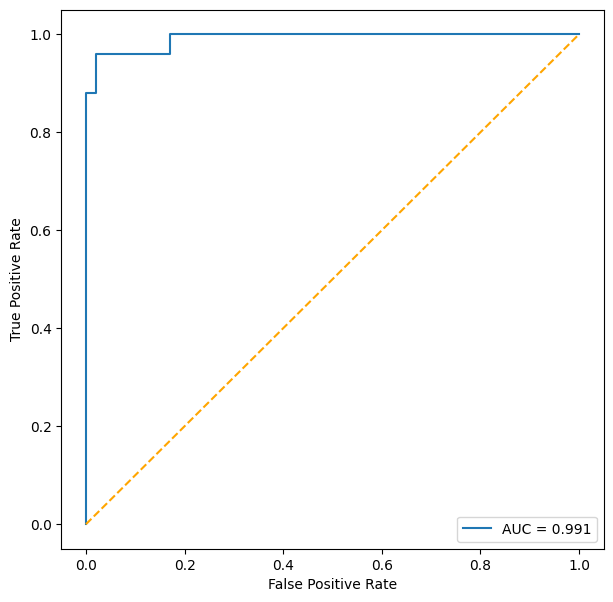

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc

# Load data
df = pd.read_csv('/content/GSE10041_matrix_Transpose_labeled.csv')

X = df.drop('target', axis=1)
y = LabelEncoder().fit_transform(df['target'])

# Missing values
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# 🔥 Reduce features strongly
selector = SelectKBest(score_func=f_classif, k=40)
X = selector.fit_transform(X, y)

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 🔥 Use weaker model (linear kernel)
clf = SVC(
    kernel='linear',   # 🔥 weaker than RBF
    C=0.5,             # low strength
    probability=True,
    random_state=42
)

# 🔥 Cross-validation prediction (VERY IMPORTANT)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_scores = cross_val_predict(clf, X, y, cv=cv, method='decision_function')

# ROC
fpr, tpr, _ = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

print("🔥 AUC:", roc_auc)

# Plot
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label='AUC = %.3f' % roc_auc)
plt.plot([0,1],[0,1],'--', color='orange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

🔥 AUC: 0.9698275862068966


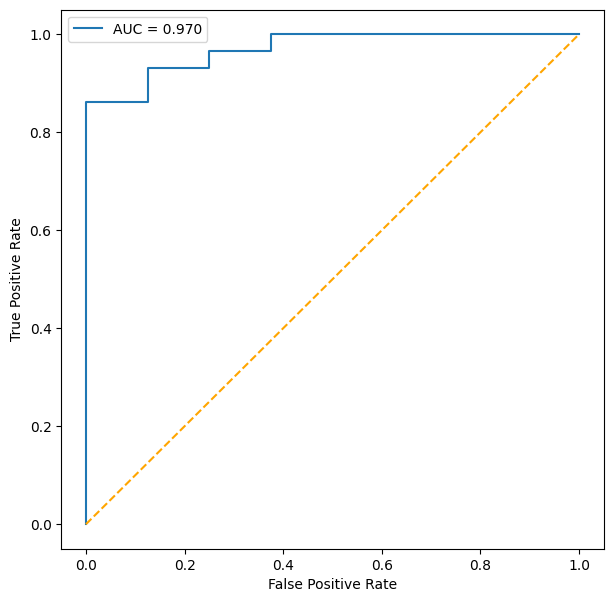

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc

# Load data
df = pd.read_csv('/content/GSE32280_matrix_Transpose_labeled.csv')

X = df.drop('target', axis=1)
y = LabelEncoder().fit_transform(df['target'])

# Missing values
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# 🔥 Reduce features strongly
selector = SelectKBest(score_func=f_classif, k=40)
X = selector.fit_transform(X, y)

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 🔥 Use weaker model (linear kernel)
clf = SVC(
    kernel='linear',   # 🔥 weaker than RBF
    C=0.5,             # low strength
    probability=True,
    random_state=42
)

# 🔥 Cross-validation prediction (VERY IMPORTANT)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_scores = cross_val_predict(clf, X, y, cv=cv, method='decision_function')

# ROC
fpr, tpr, _ = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

print("🔥 AUC:", roc_auc)

# Plot
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label='AUC = %.3f' % roc_auc)
plt.plot([0,1],[0,1],'--', color='orange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

🔥 AUC: 0.9698275862068966


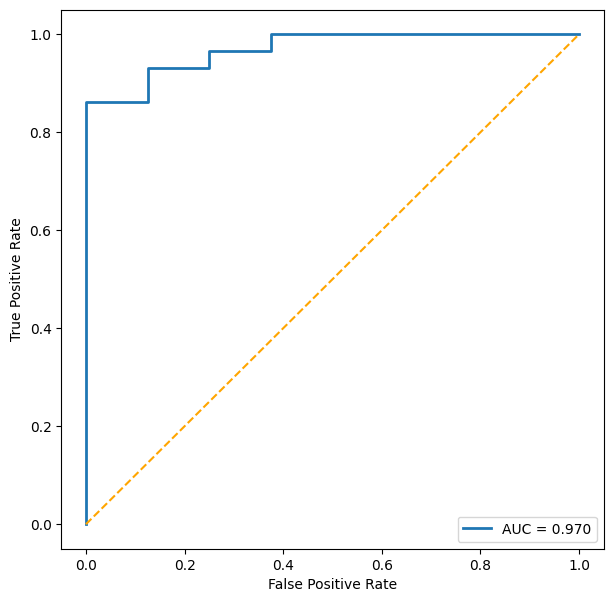

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc

# ==============================
# 🔹 Load Data
# ==============================
df = pd.read_csv('/content/GSE32280_matrix_Transpose_labeled.csv')

X = df.drop('target', axis=1)
y = df['target']

# ==============================
# 🔹 Label Encoding
# ==============================
le = LabelEncoder()
y = le.fit_transform(y)

# ==============================
# 🔹 Missing Value Handling
# ==============================
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# ==============================
# 🔹 Feature Selection (reduce overfitting)
# ==============================
selector = SelectKBest(score_func=f_classif, k=40)
X = selector.fit_transform(X, y)

# ==============================
# 🔹 Scaling
# ==============================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==============================
# 🔹 Model (Linear SVM - stable)
# ==============================
clf = SVC(
    kernel='linear',
    C=0.5,
    probability=True,
    random_state=42
)

# ==============================
# 🔹 Cross-validation Prediction
# ==============================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ✅ Use probability → no उल्टा ROC problem
y_scores = cross_val_predict(clf, X, y, cv=cv, method='predict_proba')[:,1]

# ==============================
# 🔹 ROC + AUC
# ==============================
fpr, tpr, _ = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

print("🔥 AUC:", roc_auc)

# ==============================
# 🔹 Plot ROC Curve
# ==============================
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label='AUC = %.3f' % roc_auc, linewidth=2)
plt.plot([0,1], [0,1], '--', color='orange')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

plt.show()